Dataset Loaded. Shape: (53940, 10)

--- 2. Visualizing Summary & EDA Metrics ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621    

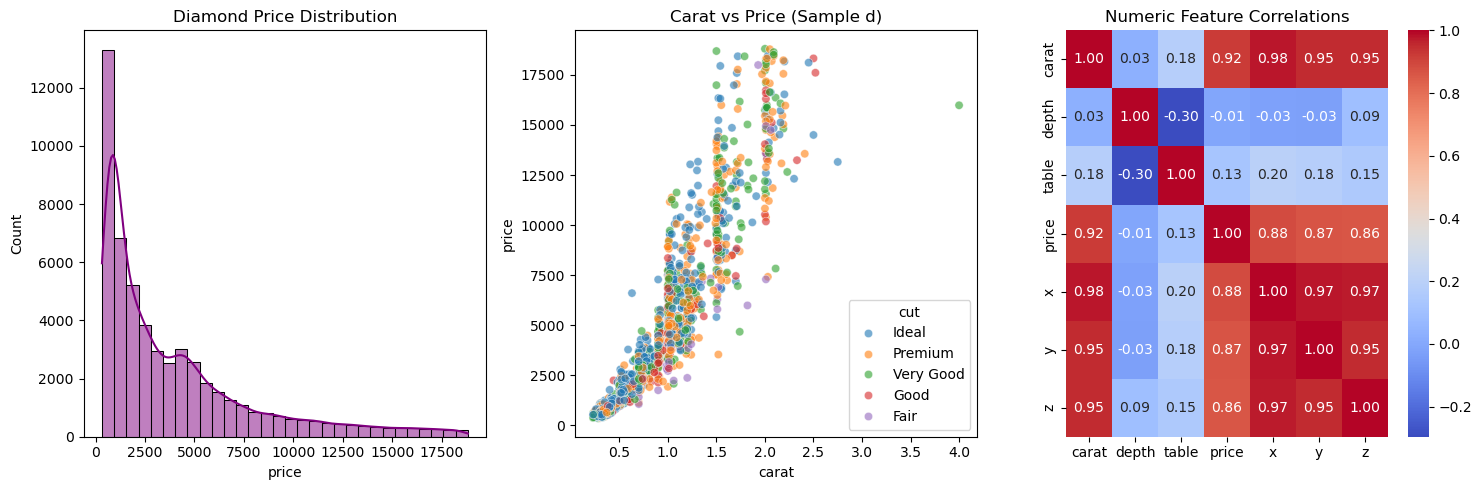


--- 3. Running Feature Engineering & Encoding ---
Feature Engineering completed successfully with fixed dtypes.

--- 4. Training Clarity Classification Model (ANN) ---
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2738 - loss: 1.7659 - val_accuracy: 0.2805 - val_loss: 1.7260
337/337 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- Classification Performance Metric Summary ---
Accuracy Score: 0.2838
              precision    recall  f1-score   support

          I1       0.00      0.00      0.00       135
         SI2       0.31      0.54      0.39      1901
         SI1       0.31      0.32      0.32      2582
         VS2       0.25      0.44      0.32      2495
         VS1       0.21      0.05      0.08      1632
        VVS2       0.29      0.01      0.01       998
        VVS1       0.19      0.02      0.03       687
          IF       0.00      0.00      0.00       354

    accuracy                           0.28     10784
   macro avg       0.20      0.17      0.14     10784
w

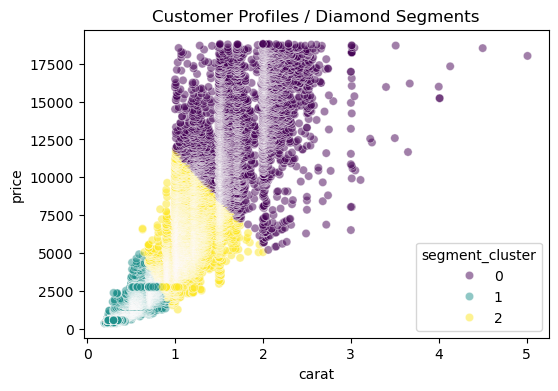


--- 7. Interacting with the Diamond AI Assistant ---

🤖 Diamond AI Assistant Online! (Type 'exit' or 'quit' to stop)



You:  What is the higest cost diamond?


Assistant: ❓ I am an AI assistant specialized in this diamond catalog!
   Try asking me:
   • 'What is the average price?'
   • 'What is the average price by cut?'
   • 'Tell me about the most expensive diamond.'
   • 'How much is a 1.5 carat diamond?'



You:  what is the most expensive diamond?


Assistant: 💎 The highest value diamond costs $18,823 USD.
   • Carat Weight: 2.29
   • Cut Grading: Premium
   • Color: I
   • Clarity: VS2


...

Assistant: 💎 The overall average diamond price within our registry is $3,930.99 USD.



You:  how much is a 2.5 carat diamond?


Assistant: 💎 Based on catalog history, a diamond weighing roughly 2.5 carats averages $15881.98 USD.



You:  exit


Assistant: Goodbye! 💎


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score, 
    mean_squared_error, r2_score, mean_absolute_error,
    silhouette_score, davies_bouldin_score
)
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# =====================================================================
# 1. READ DATASET
# =====================================================================
# Load the standard diamonds dataset from seaborn
df = sns.load_dataset('diamonds')
print("Dataset Loaded. Shape:", df.shape)

# =====================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA) REPORT
# =====================================================================
print("\n--- 2. Visualizing Summary & EDA Metrics ---")
print(df.info())
print(df.describe())

# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# EDA Visual Plots
plt.figure(figsize=(15, 5))

# Plot 1: Price Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['price'], bins=30, kde=True, color='purple')
plt.title('Diamond Price Distribution')

# Plot 2: Carat vs Price by Cut
plt.subplot(1, 3, 2)
sns.scatterplot(data=df.sample(2000, random_state=42), x='carat', y='price', hue='cut', alpha=0.6)
plt.title('Carat vs Price (Sample d)')

# Plot 3: Correlation Matrix Heatmap
plt.subplot(1, 3, 3)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numeric Feature Correlations')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. FEATURE ENGINEERING & PREPROCESSING
# =====================================================================
print("\n--- 3. Running Feature Engineering & Encoding ---")

# Step A: Drop zero-dimension outliers
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy() # Added .copy() to prevent warning

# Step B: Volume calculation feature
df['volume'] = df['x'] * df['y'] * df['z']

# Step C: Ordinal Mapping for Categorical Fields
cut_mapping = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_mapping = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_mapping = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

# Map and explicitly force the data type to regular integers
df['cut_encoded'] = df['cut'].map(cut_mapping).astype(int)
df['color_encoded'] = df['color'].map(color_mapping).astype(int)
df['clarity_encoded'] = df['clarity'].map(clarity_mapping).astype(int)

# Prepare structural features matrix (Ensure these are all float/int)
feature_cols = ['carat', 'cut_encoded', 'color_encoded', 'depth', 'table', 'x', 'y', 'z', 'volume']
X_base = df[feature_cols].astype(float) # Ensures features are clean numeric matrices

print("Feature Engineering completed successfully with fixed dtypes.")


# =====================================================================
# 4. DIAMOND CLARITY CLASSIFICATION (ANN)
# =====================================================================
print("\n--- 4. Training Clarity Classification Model (ANN) ---")
# Feedforward Neural Network (FNN), specifically a Multi-Layer Perceptron (MLP).

# Import the explicit Input layer to comply with newer Keras APIs
from tensorflow.keras.layers import Input

X_class = X_base.copy()
y_class = df['clarity_encoded']

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Scale
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Build ANN Architecture using the updated Input syntax
num_classes = len(clarity_mapping)
ann_model = Sequential([
    # FIX: Explicit Input layer replaces passing input_shape to the Dense layer
    Input(shape=(X_train_c_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Network
ann_model.fit(X_train_c_scaled, y_train_c, epochs=1, batch_size=64, validation_split=0.1, verbose=1)

# Evaluate Classification
y_pred_c_prob = ann_model.predict(X_test_c_scaled)
y_pred_c = np.argmax(y_pred_c_prob, axis=1)

print("\n--- Classification Performance Metric Summary ---")
print(f"Accuracy Score: {accuracy_score(y_test_c, y_pred_c):.4f}")
print(classification_report(y_test_c, y_pred_c, target_names=list(clarity_mapping.keys()), zero_division=0))

# =====================================================================
# 5. DIAMOND PRICE PREDICTION (REGRESSION)
# =====================================================================
print("\n--- 5. Training Price Regression Model ---")

# Include Clarity code back into regression features
X_reg = X_base.copy()
X_reg['clarity_encoded'] = df['clarity_encoded']
y_reg = df['price']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_scaler = StandardScaler()
X_train_r_scaled = reg_scaler.fit_transform(X_train_r)
X_test_r_scaled = reg_scaler.transform(X_test_r)

# Fit linear baseline or custom ensemble regressor
reg_model = LinearRegression()
reg_model.fit(X_train_r_scaled, y_train_r)

# Evaluate Regression
y_pred_r = reg_model.predict(X_test_r_scaled)

print("\n--- Regression Performance Metric Summary ---")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test_r, y_pred_r):.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_r, y_pred_r):.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")
print(f"R-squared Score (R²): {r2_score(y_test_r, y_pred_r):.4f}")

# =====================================================================
# 6. CUSTOMER SEGMENTATION (CLUSTERING)
# =====================================================================
print("\n--- 6. Running Customer Segmentation / Clustering ---")

# Segmenting diamonds based on buying behaviors (Price vs Carat weight profile)
X_cluster = df[['carat', 'price']]
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# Run KMeans with optimal structural groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['segment_cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("\n--- Clustering Performance Metric Summary ---")
# Calculating Silhouette on a sample subset for code speed
sample_idx = np.random.choice(len(X_cluster_scaled), size=3000, replace=False)
sil_score = silhouette_score(X_cluster_scaled[sample_idx], df['segment_cluster'].iloc[sample_idx])
db_score = davies_bouldin_score(X_cluster_scaled, df['segment_cluster'])

print(f"Silhouette Score (Sampled): {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")

# Visualize Customer Segments
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='carat', y='price', hue='segment_cluster', palette='viridis', alpha=0.5)
plt.title('Customer Profiles / Diamond Segments')
plt.show()

# =====================================================================
# 7. INTERACTIVE DATA-DRIVEN AI ASSISTANT
# =====================================================================
print("\n--- 7. Interacting with the Diamond AI Assistant ---")

def diamond_ai_assistant(query_text):
    """
    A lightweight, deterministic intent-matching agent that uses the
    actual processed Pandas dataframe to instantly answer context-aware questions.
    """
    query = query_text.lower().strip()
    
    if "average price" in query:
        if "cut" in query:
            res = df.groupby('cut', observed=False)['price'].mean().round(2).to_dict()
            return f"💎 The average price broken down by cut quality is:\n   {res}"
        else:
            avg_p = df['price'].mean().round(2)
            return f"💎 The overall average diamond price within our registry is ${avg_p:,} USD."
            
    elif "most expensive" in query or "highest price" in query:
        max_row = df.loc[df['price'].idxmax()]
        return (f"💎 The highest value diamond costs ${max_row['price']:,} USD.\n"
                f"   • Carat Weight: {max_row['carat']}\n"
                f"   • Cut Grading: {max_row['cut']}\n"
                f"   • Color: {max_row['color']}\n"
                f"   • Clarity: {max_row['clarity']}")
        
    elif "predict price" in query or "how much" in query or "price of" in query:
        # Extract numeric values to parse requested carat weight
        words = query.replace('carat', '').split()
        carats = [float(w) for w in words if w.replace('.', '', 1).isdigit()]
        if carats:
            input_carat = carats[0]
            # Fetch context from matching real-world data points (+/- 0.1 carat band)
            approx = df[df['carat'].between(input_carat - 0.1, input_carat + 0.1)]['price'].mean()
            if pd.isna(approx):
                return f"❌ I couldn't find enough diamonds around {input_carat} carats to estimate a price."
            return f"💎 Based on catalog history, a diamond weighing roughly {input_carat} carats averages ${approx:.2f} USD."
            
    return ("❓ I am an AI assistant specialized in this diamond catalog!\n"
            "   Try asking me:\n"
            "   • 'What is the average price?'\n"
            "   • 'What is the average price by cut?'\n"
            "   • 'Tell me about the most expensive diamond.'\n"
            "   • 'How much is a 1.5 carat diamond?'")

# Interactive Terminal Loop
print("\n🤖 Diamond AI Assistant Online! (Type 'exit' or 'quit' to stop)")
print("=================================================================")
while True:
    try:
        user_query = input("\nYou: ")
        if user_query.lower().strip() in ['exit', 'quit']:
            print("Assistant: Goodbye! 💎")
            break
        
        if not user_query.strip():
            continue
            
        response = diamond_ai_assistant(user_query)
        print(f"Assistant: {response}")
        
    except KeyboardInterrupt:
        print("\nAssistant: Goodbye! 💎")
        break
